# EDA and KPI

The data was downloaded from METABRIC in cBioPortal. The data contains 2509 female patients.

## Description of the data
1. One row = one patient (primary tumor sample)
2. No repeated measurements; each patient has exactly 1 sample
3. Target: Binary overall survival (0=living, 1=deceased)
4. Secondary target: Overall Survival (Months) for survival analysis

### Step 1: Data audit

In [ ]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('brca_metabric/brca_metabric_clinical_data.tsv', sep='\t')

# Understand the columns
total = len(df)
audit_rows = []

for col in df.columns:
    n_unique = df[col].nunique() # Get total number of unique values in a column
    n_null = df[col].isna().sum() # Get the missing values per column
    pct_missing = (n_null / total)*100 
    pct_complete = (1 - n_null / total) * 100 # 1-null columns = percentage completeness of a column (feature)
    dtype = str(df[col].dtype) # Data type of each column
    top_val = df[col].mode().iloc[0] if not df[col].mode().empty else 'N/A' # add most frequent value per column if mode is present else NA
    top_freq = df[col].value_counts().iloc[0] if n_unique > 0 else 0 # Get the frequency count per column

    audit_rows.append({
        'column': col,
        'dtype': dtype,
        'unique': n_unique,
        'non-null': total - n_null,
        'missing_pct': round(pct_missing,2),
        'completeness_pct': round(pct_complete, 2),
        'top_value': top_val,
        'top_freq': top_freq,
    })

audit_df = pd.DataFrame(audit_rows)
audit_df.sort_values(by='missing_pct', ascending=False)

,column,dtype,unique,non-null,missing_pct,completeness_pct,top_value,top_freq
34,3-Gene classifier subtype,object,4,1764,29.69,70.31,ER+/HER2- Low Prolif,640
37,Tumor Stage,float64,5,1788,28.74,71.26,2.0,979
20,Primary Tumor Laterality,object,2,1870,25.47,74.53,Left,973
7,Cellularity,object,3,1917,23.60,76.40,High,965
4,Type of Breast Surgery,object,2,1955,22.08,77.92,MASTECTOMY,1170
19,Integrative Cluster,object,11,1980,21.08,78.92,8,299
14,HER2 status measured by SNP6,object,4,1980,21.08,78.92,NEUTRAL,1436
28,Radio Therapy,object,2,1980,21.08,78.92,YES,1173
27,PR Status,object,2,1980,21.08,78.92,Positive,1040
18,Inferred Menopausal State,object,2,1980,21.08,78.92,Post,1556


In [2]:
#Identify constant and near constant columns in the dataset
for _, row in audit_df.iterrows():
    if row['unique'] <= 1:
        print(f"Constant: {row['column']} → {row['top_value']}")
    elif row['unique'] == 2 and row['top_freq'] / total > 0.95:
        print(f"Near constant: {row['column']} → {row['top_value']} "
              f"({row['top_freq']}/{total} = {row['top_freq']/total*100:.1f}%)")
        
# Note that the fraction of instances covered under near constant feature was chosen \
# because if a feature values is same for the 95% of the instances then it can be assumed to be constant \
# If we use the fraction value of 0.7 then we get two near costant features namely \
# ER status measured by IHC (Positve (1817/2509 = 72.4%)) and ER Status (Positive (1825/2509 = 72.7%))

Constant: Study ID → brca_metabric
Constant: Cancer Type → Breast Cancer
Constant: Number of Samples Per Patient → 1
Constant: Sample Type → Primary
Constant: Sex → Female


- Since the number of patients per sample is constant, we should drop the column before processing further.

In [3]:
# Get the summary of numeric columns in the data
df_new = df.copy()
df_new = df_new.drop(columns=['Number of Samples Per Patient'], axis=1)
num_cols = df_new.select_dtypes(include=[np.number]).columns.tolist()
df_new[num_cols].describe().round(2)

,Age at Diagnosis,Cohort,Neoplasm Histologic Grade,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Relapse Free Status (Months),TMB (nonsynonymous),Tumor Size,Tumor Stage
count,2498.00,2498.00,2388.00,2243.00,2358.00,2287.00,1981.00,2388.00,2509.00,2360.00,1788.00
mean,60.42,2.90,2.41,1.95,5.59,4.03,125.24,110.29,6.85,26.22,1.71
std,13.03,1.96,0.65,4.02,3.99,1.19,76.11,77.54,5.32,15.37,0.66
min,21.93,1.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00
25%,50.92,1.00,2.00,0.00,3.00,3.05,60.87,41.10,3.92,17.00,1.00
50%,61.11,3.00,3.00,0.00,5.00,4.04,116.47,100.42,6.54,22.41,2.00
75%,70.00,4.00,3.00,2.00,7.00,5.04,185.13,169.87,9.15,30.00,2.00
max,96.29,9.00,3.00,45.00,81.00,7.20,355.20,389.33,104.60,182.00,4.00


In our project, Overall Survival (Months), Overall Survival Status, and Patient's Vital Status represent target variables, we need to understand values in these columns

In [4]:
# Understanding the target variables
# Overall survival status and patient vital status columns carry the same values

print(df_new['Overall Survival Status'].value_counts(dropna=False))

print(f"\nSurvival months range: ",
      f"{df_new['Overall Survival (Months)'].min():.1f} – ",f"{df_new['Overall Survival (Months)'].max():.1f}")
print(f"Median survival months: {df_new['Overall Survival (Months)'].median():.1f}")

Overall Survival Status
1:DECEASED    1144
0:LIVING       837
NaN            528
Name: count, dtype: int64

Survival months range:  0.0 –  355.2
Median survival months: 116.5


# Identify patients with missing data

In [121]:
# For the missingness analysis, we will make use of missingno package from pip
#!pip install missingno --no-cache-dir

# Load all the required python libraries
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Remember, we are using df_new moving forward. df_new was created by removing column: Number of Patients Per Sample

total = len(df_new) # total number of instances in the data

missing_per_column = df_new.isnull().sum() 

miss_pct = (missing_per_column / total * 100).round(2)

miss_df = pd.DataFrame({
    'Missing': missing_per_column.values,
    'Pct': round(miss_pct, 2)
}).sort_values('Pct', ascending=False)

miss_df

,Missing,Pct
3-Gene classifier subtype,745,29.69
Tumor Stage,721,28.74
Primary Tumor Laterality,639,25.47
Cellularity,592,23.60
Type of Breast Surgery,554,22.08
Integrative Cluster,529,21.08
Hormone Therapy,529,21.08
Radio Therapy,529,21.08
PR Status,529,21.08
Inferred Menopausal State,529,21.08


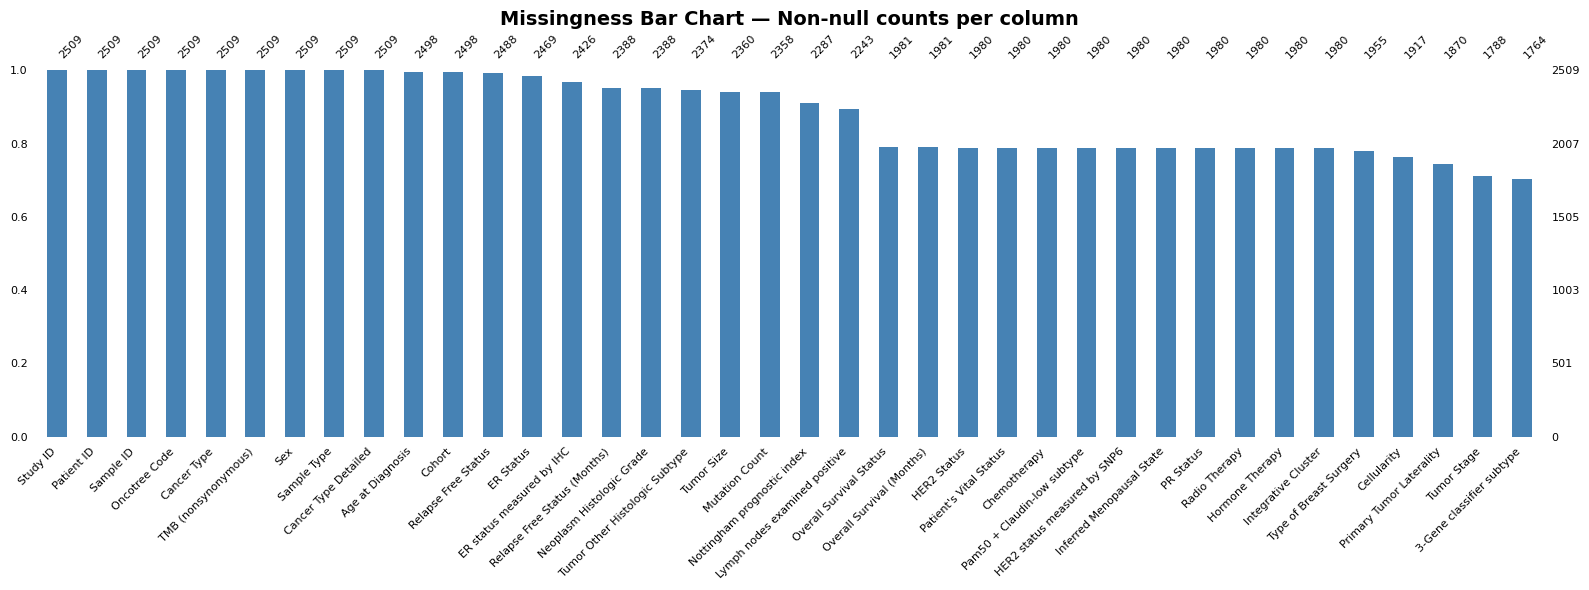

In [122]:
# columns ordered from fewest missing → most missing
# All the plots showing missignness will be shorted.

#1. Bar chart
cols_sorted = df_new.isnull().sum().sort_values().index
df_new = df_new[cols_sorted]

fig, ax = plt.subplots(figsize=(16, 6))
msno.bar(df_new, ax=ax, fontsize=8, color='steelblue')
ax.set_title('Missingness Bar Chart — Non-null counts per column', 
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
#plt.savefig('missingness_bar.png', dpi=150, bbox_inches='tight')

plt.close()

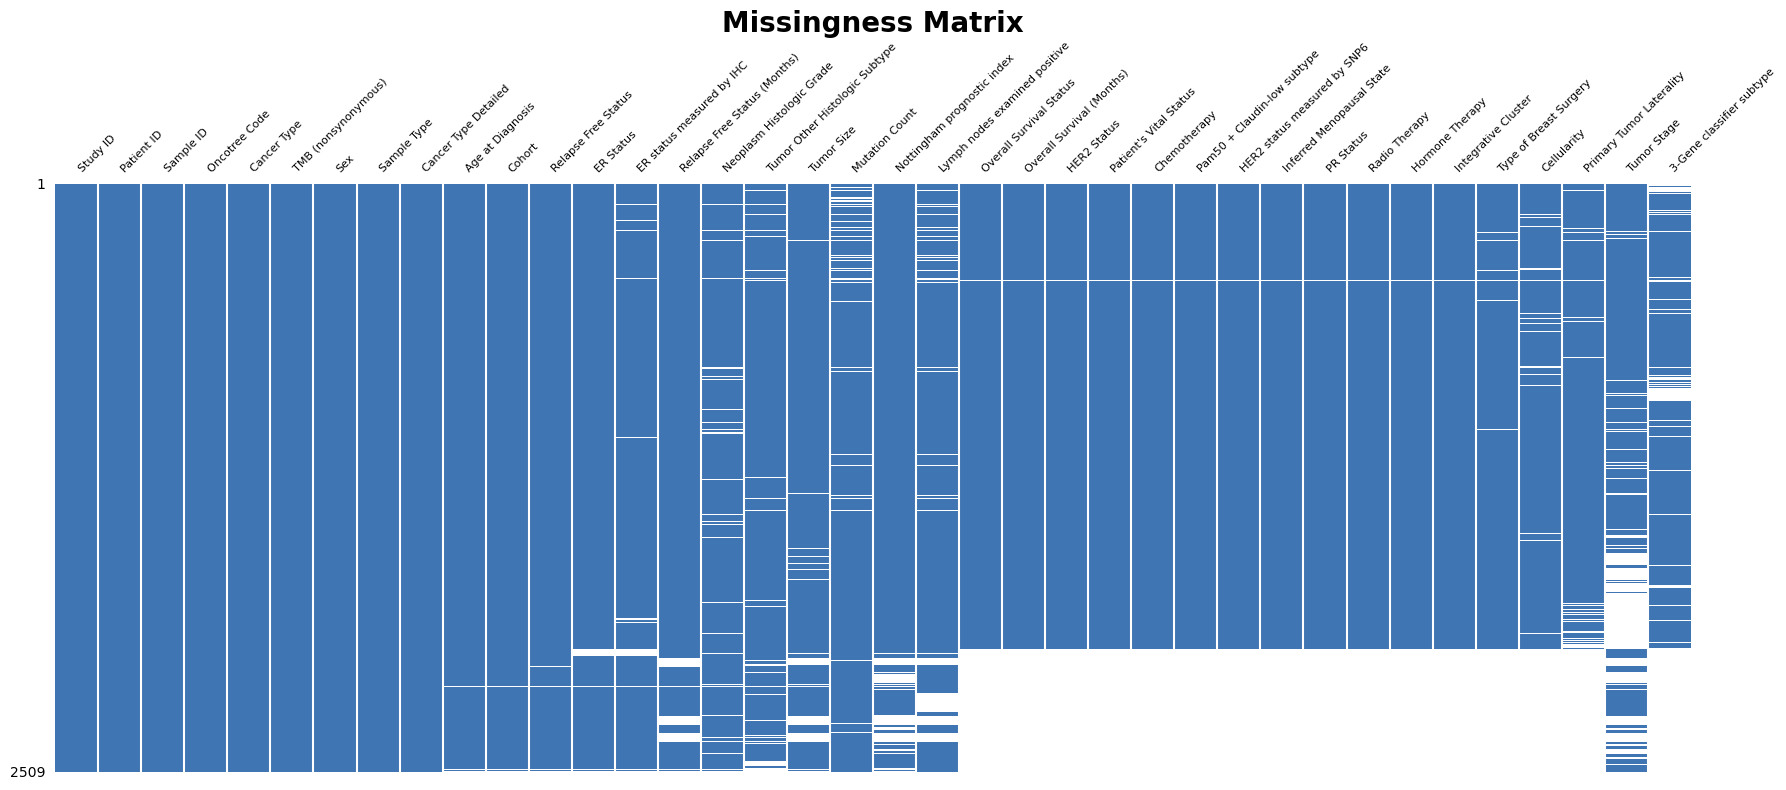


White is missingness



In [123]:
#2. Matrix
fig, ax = plt.subplots(figsize=(18, 8))
msno.matrix(df_new, ax=ax, fontsize=8, sparkline=False, color=(0.25, 0.46, 0.70))
ax.set_title('Missingness Matrix', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()
print(f'\nWhite is missingness\n')

Note: Nullity correlation shows how strongly the missingness of one column is related to the missingness of another column.

Empty cells in the heatmap represent features with no missing values.



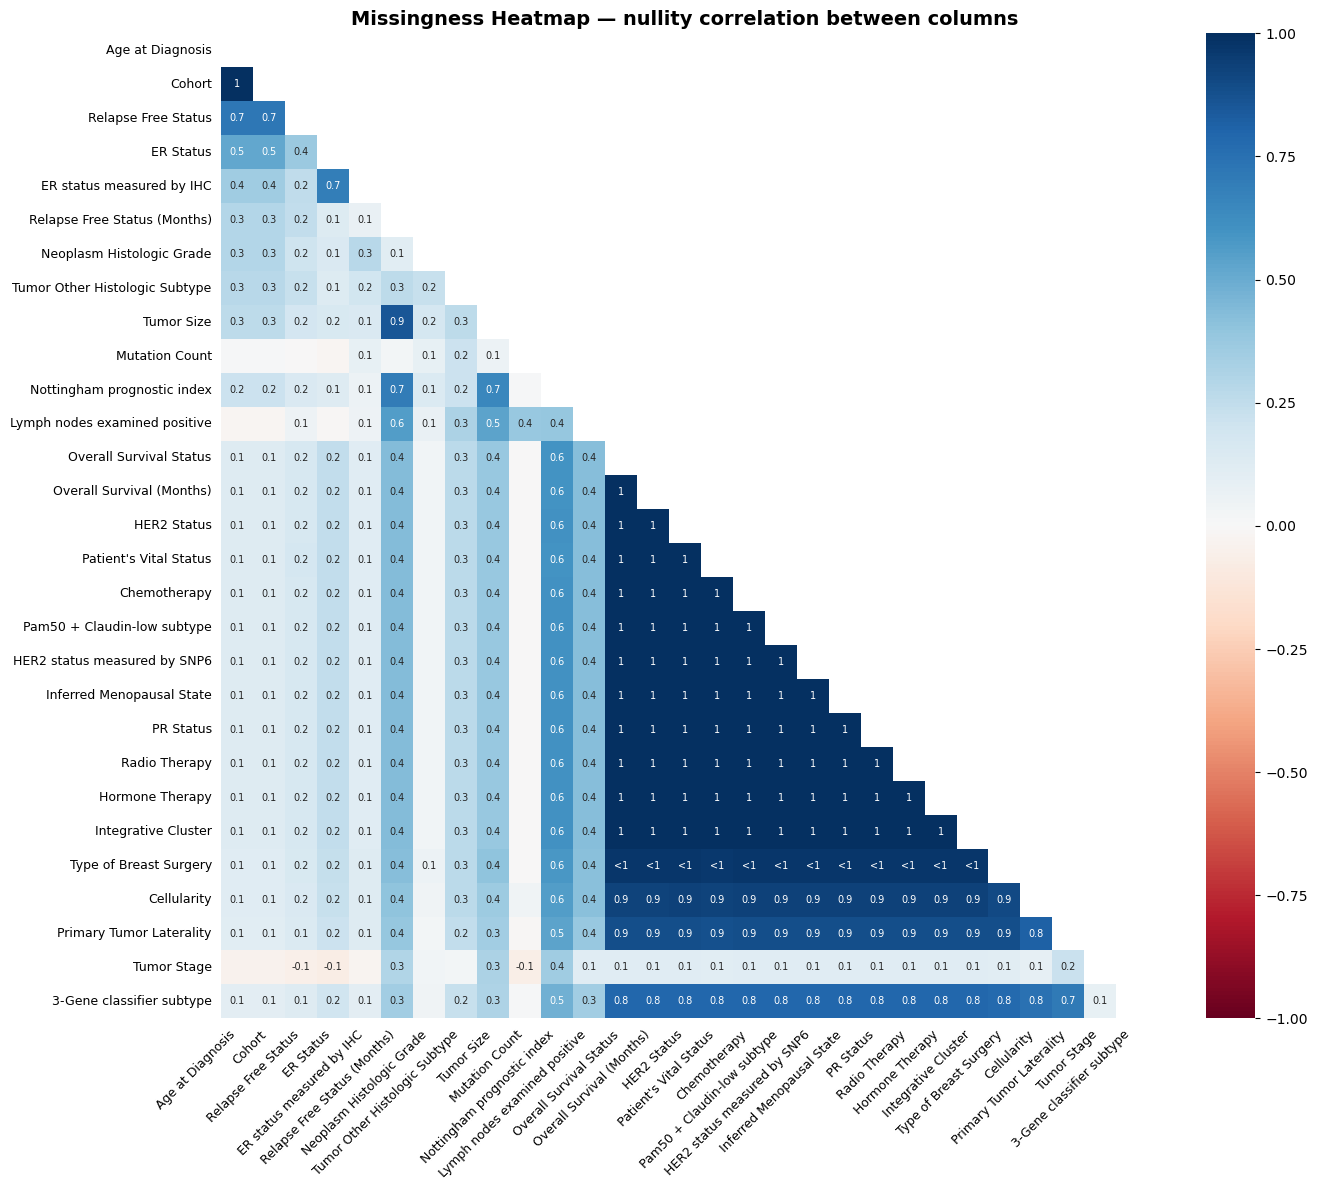

In [124]:
#Heatmap (nullity correlation)
print('Note: Nullity correlation shows how strongly the missingness of one column is related to the missingness of another column.\n')
print('Empty cells in the heatmap represent features with no missing values.\n')

fig, ax = plt.subplots(figsize=(14, 12))
msno.heatmap(df_new, ax=ax, fontsize=9)
ax.set_title('Missingness Heatmap — nullity correlation between columns',
    fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

plt.close()

Note: Columns that go missing together cluster together



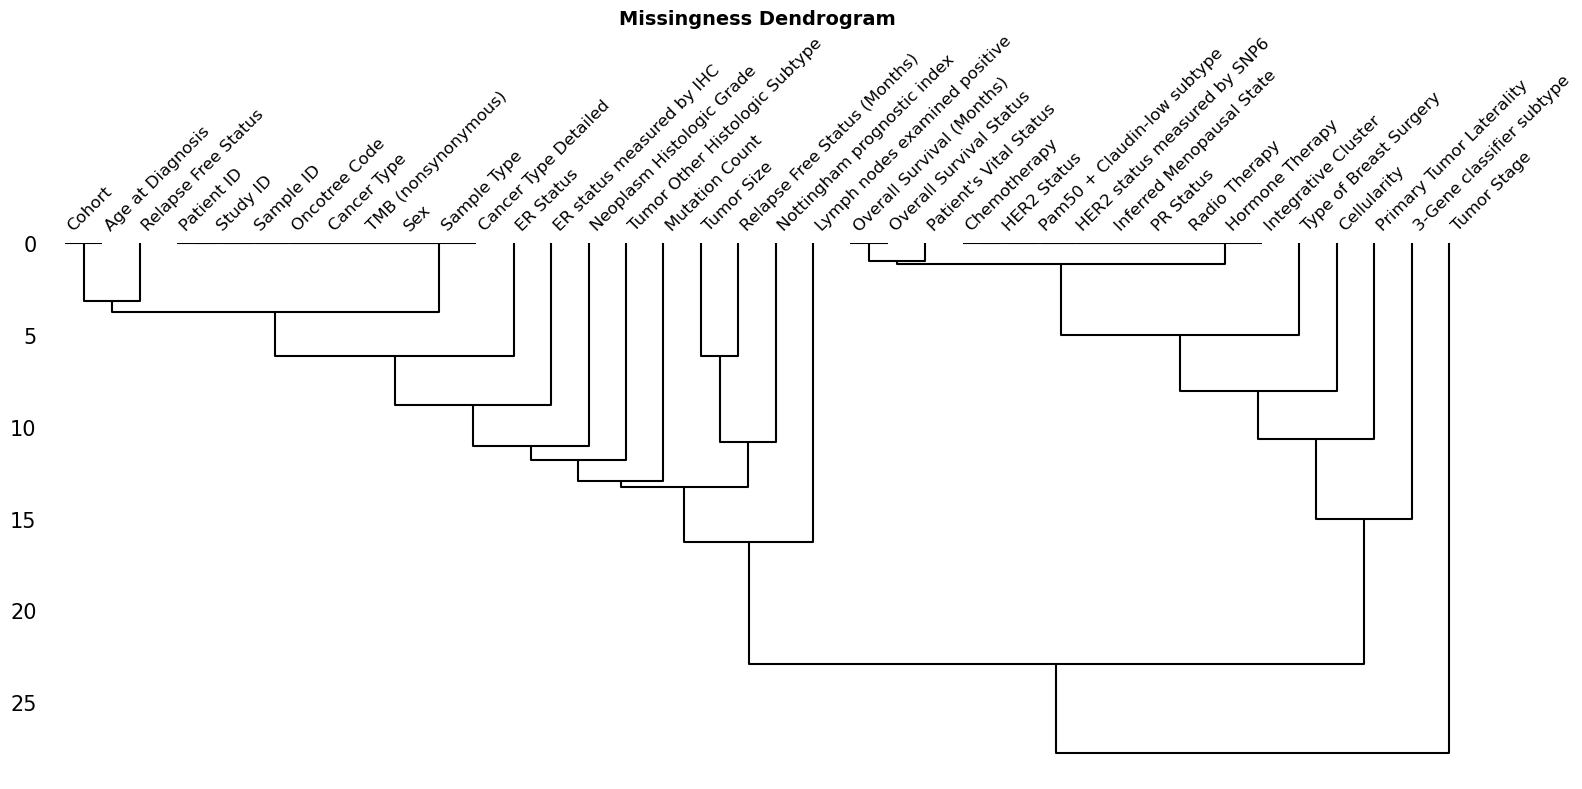

In [125]:
# 3. Dendrogram (hierarchical clustering of missingness)
print('Note: Columns that go missing together cluster together\n')
fig, ax = plt.subplots(figsize=(16, 8))
msno.dendrogram(df_new, ax=ax, fontsize=12)

ax.set_title('Missingness Dendrogram',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

#### Check if the missigness of the data is random or structured
- There are 529 patients for which Patient's Vital Status is missing
- Before moving on we need to check what are the features that have 529 missing values.

*Note: There are 528 patients for which **Overall Survial Status** and Months are unknown*

In [126]:
#Identify the features with 529 missing values

block_529 = miss_df[miss_df['Missing'] == 529].index.tolist()

print(f"Columns with exactly 529 missing values: {len(block_529)} columns\n")
for c in block_529:
    print(f"- {c}")

Columns with exactly 529 missing values: 10 columns

- Integrative Cluster
- Hormone Therapy
- Radio Therapy
- PR Status
- Inferred Menopausal State
- Pam50 + Claudin-low subtype
- HER2 status measured by SNP6
- Chemotherapy
- Patient's Vital Status
- HER2 Status


In [127]:
# Verify the missing columns in the dataset and find the if these are the same patients that have these missing values
null_masks = df[block_529].isnull()
all_same = null_masks.all(axis=1).sum()

print(f"\nPatients missing ALL {len(block_529)} columns: {all_same}")
print(f"Confirms these are the SAME {all_same} patients. Thus it shows that missingness is not random")


Patients missing ALL 10 columns: 528
Confirms these are the SAME 528 patients. Thus it shows that missingness is not random


*Note: As you can see above there are 528 patients with 10 missing columns, this is because we have 528 patients with missing overall status. Thus just 528 patients have the missing values*

Now the big question is: can we say anything about the survival of these 528 patients with missing values?
Since, there is no overall survial data for these patients, next best measure is relapse free status/months. Could the data be missing because the pateints recovered and did not come back for the further checkups?

In [128]:
# Who are the 529? Check if they share a cohort
print(f'Note: In this analysis, "Annotated patients" represents the data where the 10 columns are not missing\n')

block_patients = df_new[null_masks.all(axis=1)]
non_block = df_new[~null_masks.all(axis=1)]
print(f"529-block patients\nAge range: "
      f"{block_patients['Age at Diagnosis'].min():.0f}–"
      f"{block_patients['Age at Diagnosis'].max():.0f}\n")

print(f"Annotated patients\nAge range: "
      f"{non_block['Age at Diagnosis'].min():.0f}–"
      f"{non_block['Age at Diagnosis'].max():.0f}")

print("\nMISSINGNESS vs. SURVIVAL")
print("Question: Does being in the 529-block correlate with relapse status?\n")

# The 528 patients do have Relapse Free Status (99.2% complete)
print(f"529-block with their relapse rates:")
print(block_patients['Relapse Free Status'].value_counts(normalize=True).round(3)*100) # Count normalized without NAN values

print(f"\nAnnotated patients with their relapse rates:")
print(non_block['Relapse Free Status'].value_counts(normalize=True).round(3)*100)

Note: In this analysis, "Annotated patients" represents the data where the 10 columns are not missing

529-block patients
Age range: 27–89

Annotated patients
Age range: 22–96

MISSINGNESS vs. SURVIVAL
Question: Does being in the 529-block correlate with relapse status?

529-block with their relapse rates:
Relapse Free Status
0:Not Recurred    60.8
1:Recurred        39.2
Name: proportion, dtype: float64

Annotated patients with their relapse rates:
Relapse Free Status
0:Not Recurred    59.4
1:Recurred        40.6
Name: proportion, dtype: float64


As shown in the results above, patient age range and percentages of "Not Recurred" & "Recurred" remain comparable. The explanation for this could be because data for these pateints was missed due to administrative errors. In studies like METABRIC, the data comes from **patient registries** and even if a patient stops showing up for a hospital visit, their records get updated through this repo. The fact that treatment columns (Chemotherapy, Hormone Therapy, Radio Therapy) are also missing for the same patients further supports the administrative explanation. 

*Recommendations*: Thus, instances belonging patients with missing 10 columns should be dropped as this is not because the data was not randomly lost. 

In [129]:
print("\n\nSporadic/random missigness (data missing randomly from anywhere)")

sporadic_cols = miss_df[(miss_df['Missing'] > 0) & (miss_df['Missing'] != 529)].index.tolist()

print(f"Columns with sporadic or random missingness: {len(sporadic_cols)}")

for c in sporadic_cols:
    n = df_new[c].isna().sum()
    # Of the missing, how many are in the 529 patients block vs. sporadic?
    in_block = block_patients[c].isna().sum()
    out_block = non_block[c].isna().sum()
    print(f" - {c}: {n} missing total → {in_block} in missing patient block + {out_block} sporadic")



Sporadic/random missigness (data missing randomly from anywhere)
Columns with sporadic or random missingness: 19
 - 3-Gene classifier subtype: 745 missing total → 528 in missing patient block + 217 sporadic
 - Tumor Stage: 721 missing total → 206 in missing patient block + 515 sporadic
 - Primary Tumor Laterality: 639 missing total → 528 in missing patient block + 111 sporadic
 - Cellularity: 592 missing total → 528 in missing patient block + 64 sporadic
 - Type of Breast Surgery: 554 missing total → 528 in missing patient block + 26 sporadic
 - Overall Survival (Months): 528 missing total → 528 in missing patient block + 0 sporadic
 - Overall Survival Status: 528 missing total → 528 in missing patient block + 0 sporadic
 - Lymph nodes examined positive: 266 missing total → 190 in missing patient block + 76 sporadic
 - Nottingham prognostic index: 222 missing total → 221 in missing patient block + 1 sporadic
 - Mutation Count: 151 missing total → 30 in missing patient block + 121 spo

### METABRIC data imputation strategy summary

**Total patients:** 2,509 | **Block-missing patients:** 528 | **Annotated data:** 1,981

#### Imputation Decision Table

| Column | Sporadic Missing | Strategy | Recommendation |
|--------|:----------------:|----------|-----------|
| Overall Survival Status/Months | 0 | - | Target: never impute; Drop 528 patients |
| Relapse Free Status/Months | 0 | - | Keep as secondary target; not a feature |
| ER Status | 0 | No action | Complete in annotated cohort |
| Cohort & Age at Diagnosis | 0 | No action | Complete in annotated cohort |
| 3-Gene Classifier | 217 | - | Similar information as PAM50+ Claudin-low subtype; Further analysis needed |
| Tumor Stage | 515 | - | Similar information as NPI; Further analysis needed |
| ER status by IHC | 43 | Drop column | Duplicate of ER Status |
| Cellularity | 64 | Fill as "Unknown" | - |
| Surgery Type | 26 | Fill as "Unknown" | - |
| Laterality | 111 | Fill as "Unknown" | - |
| Histologic Subtype | 44 | Fill as "Unknown" | - |
| Histologic Grade | 88 | Mode within PAM50 group | Strong subtype–grade link |
| Mutation Count | 121 | Impute | - |
| Lymph Nodes Positive | 76 | Impute | - |
| Tumor Size | 26 | Impute | - |
| NPI | 88 | Recalculate from formula | NPI = 0.2 × tumor diameter + histological grade (1–3) + lymph node stage (1–3) |

In [131]:
# Save the annotated data
non_block.to_csv('Final_metabric_data.tsv', sep='\t', index=False)